# NB07 — Vector Databases and FAISS  |  Claude Assisted

**NLP Workshop Series** | Quran Translations Dataset (6,236 verses) | `daryabadi` column

---

> *"Finding one relevant sentence in a billion is not a search problem — it is an engineering problem. FAISS is the solution."*

In NB06 we built a fully working semantic search engine using SBERT embeddings and brute-force cosine similarity over all 6,236 verses. In this notebook we confront the **scaling wall**: what happens when your corpus grows to 1 million, 100 million, or 1 billion vectors? We answer that question with **FAISS** — Facebook AI Similarity Search.

---

## Section 0 — Introduction and Workshop Roadmap

### 8-Notebook NLP Workshop: Complete Roadmap

```
+------------------------------------------------------------------+
|          FROM BAG-OF-WORDS TO EMBEDDINGS: NLP WORKSHOP           |
+--------+---------------------------------------------------------+
| NB01   | Text Preprocessing and Bag-of-Words (BoW)               |
|        | Keywords, tokenisation, stop-word removal, TF            |
+--------+---------------------------------------------------------+
| NB02   | TF-IDF and Ranked Retrieval                              |
|        | Inverse document frequency, cosine similarity            |
+--------+---------------------------------------------------------+
| NB03   | N-Grams and Context Windows                              |
|        | Bigrams, trigrams, language models                       |
+--------+---------------------------------------------------------+
| NB04   | Word2Vec Embeddings                                      |
|        | CBOW, Skip-gram, dense word vectors                      |
+--------+---------------------------------------------------------+
| NB05   | FastText and Subword Embeddings                          |
|        | Character n-grams, OOV words, morphology                 |
+--------+---------------------------------------------------------+
| NB06   | Sentence Embeddings and Semantic Search                  |
|        | SBERT, dense sentence vectors, full semantic search      |
+--------+---------------------------------------------------------+
| NB07   | ** VECTOR DATABASES AND FAISS **              <-- NOW   |
|        | Approximate nearest neighbours, billion-scale search     |
+--------+---------------------------------------------------------+
| NB08   | Retrieval-Augmented Generation (RAG)                    |
|        | Combining search with LLMs for question answering        |
+--------+---------------------------------------------------------+
```

---

### Recap: What NB06 Built

In NB06 we:
1. Loaded all 6,236 Daryabadi verses from the Quran translations dataset
2. Encoded every verse into a **384-dimensional SBERT vector** using `all-MiniLM-L6-v2`
3. For each user query, encoded the query the same way and computed **cosine similarity** against all 6,236 verse vectors
4. Returned the top-k most similar verses

This produced genuinely excellent search quality. The search engine understood that a query for "mercy and forgiveness" should return verses about compassion, grace, and divine pardon — even when those exact words do not appear in the verse.

**The fundamental operation:** cosine similarity between the query vector and every single corpus vector.

```
For N = 6,236:    scores = query_vec  @  corpus_matrix.T    # shape (6236,)
```

This is a **dense matrix multiplication** — O(N) per query, where N = number of vectors.

---

### The Scaling Problem

For N = 6,236, the brute-force approach is fast enough. But search is used at scale:

| Corpus | N (vectors) | O(N) search time |
|---|---|---|
| Quran verses | 6,236 | ~0.5 ms |
| Wikipedia paragraphs | 21,000,000 | ~1,700 ms |
| Common Crawl (web) | 1,000,000,000 | ~80,000 ms (80 seconds!) |
| Entire internet | ~100,000,000,000 | Days per query |

Brute force does not scale. We need a smarter approach.

---

### This Notebook's Objectives

By the end of NB07 you will be able to:

1. Explain why brute-force cosine similarity is O(N) and why that matters at scale
2. Describe what a vector database is and how it differs from a traditional database
3. Understand the main FAISS index types: `IndexFlatIP`, `IndexIVFFlat`, `IndexHNSW`
4. Build, populate, and query FAISS indexes over 6,236 verse embeddings
5. Measure and compare query speed: brute force vs FAISS exact vs FAISS approximate
6. Understand the speed-accuracy tradeoff in approximate nearest neighbour (ANN) search
7. Save and load a FAISS index for production deployment
8. Build a clean end-to-end `QuranSearchEngine` class combining SBERT + FAISS

## Section 1 — The Scaling Problem

### Brute-Force Cosine Similarity: O(N) Per Query

When we run `cosine_similarity(query_vec, corpus_matrix)`, numpy performs the following operations:

1. **Dot product:** multiply the 384-dim query vector against every one of the N 384-dim corpus vectors — that is `N × 384` multiply-add operations
2. **Norm division:** divide each score by the product of the two norms (already 1.0 for unit-normalised vectors, so this is free)
3. **Argsort:** find the top-k indices from N scores

Step 1 scales linearly with N: double the corpus size, double the query time. For N = 1,000,000,000 (one billion), even with modern CPUs capable of billions of floating-point operations per second, a single query takes tens of seconds.

**Real-world implication:** If your search system serves 10,000 queries per second (a modest web service), brute force over 1B vectors is simply impossible.

### Approximate Nearest Neighbour (ANN) Search

The key insight that enables scalable vector search:

> **We do not need the exact nearest neighbour. We need one that is very close to the exact nearest neighbour.**

If the true top result has a cosine similarity of 0.87 and our approximate search returns a result with similarity 0.86, the user cannot tell the difference. The result is still highly relevant.

Trading a tiny amount of accuracy for a 100x–1000x speedup is an excellent engineering tradeoff. This is called **Approximate Nearest Neighbour (ANN)** search, and FAISS is one of the best ANN libraries ever built.

In [1]:
import os
import numpy as np
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

# ---- Robust dataset loader ----
def load_dataset(filename='quran_translations.csv'):
    candidates = [
        os.path.join('..', filename),
        filename,
        os.path.join('..', '..', filename),
        os.path.join(os.path.dirname(os.getcwd()), filename),
    ]
    for path in candidates:
        if os.path.exists(path):
            df = pd.read_csv(path)
            print('Dataset loaded from:', os.path.abspath(path))
            print('Shape:', df.shape)
            return df
    raise FileNotFoundError('quran_translations.csv not found. Tried: ' + str(candidates))

df = load_dataset()
df = df.dropna(subset=['daryabadi']).reset_index(drop=True)
verses = df['daryabadi'].tolist()
print('Total verses (daryabadi):', len(verses))
print('Sample verse 0:', verses[0][:80])

Dataset loaded from: d:\Haq Nawaz\Teaching\NLP\BOW-to-Embeddings\quran_translations.csv
Shape: (6236, 18)
Total verses (daryabadi): 6236
Sample verse 0: In the name of Allah, the Compassionate, the Merciful.


In [2]:
import numpy as np
import time
from sklearn.metrics.pairwise import cosine_similarity

# Simulate brute-force timing at different corpus sizes
# We use random float32 vectors of dimension 384 (same as SBERT)
DIM = 384
SIZES = [1000, 6236, 50000, 200000, 1000000]
NUM_QUERIES = 5

print('Brute-force cosine similarity timing (dim=384)')
print('=' * 55)
print('{:<15} {:<20} {:<20}'.format('Corpus Size', 'Avg Query Time (ms)', 'Extrapolated'))
print('-' * 55)

times_ms = []
for n in SIZES:
    # Allocate corpus and query vectors (unit-normalised)
    corpus = np.random.randn(n, DIM).astype(np.float32)
    norms = np.linalg.norm(corpus, axis=1, keepdims=True)
    corpus = corpus / norms
    query = np.random.randn(1, DIM).astype(np.float32)
    query = query / np.linalg.norm(query)
    
    elapsed_list = []
    for _ in range(NUM_QUERIES):
        t0 = time.perf_counter()
        scores = cosine_similarity(query, corpus)
        top_idx = np.argmax(scores)
        t1 = time.perf_counter()
        elapsed_list.append((t1 - t0) * 1000)
    
    avg_ms = np.mean(elapsed_list)
    times_ms.append(avg_ms)
    note = '(baseline)' if n == 6236 else ''
    print('{:<15} {:<20} {:<20}'.format(
        f'{n:,}',
        str(round(avg_ms, 2)) + ' ms',
        note
    ))

print()
print('Memory for corpus vectors (float32 x dim=384):')
for n in SIZES:
    mem_mb = n * DIM * 4 / 1024 / 1024
    print('  N =', f'{n:>9,}', '  Memory:', round(mem_mb, 1), 'MB')

Brute-force cosine similarity timing (dim=384)
Corpus Size     Avg Query Time (ms)  Extrapolated        
-------------------------------------------------------
1,000           1.21 ms                                  
6,236           9.43 ms              (baseline)          
50,000          58.39 ms                                 
200,000         261.72 ms                                
1,000,000       1290.24 ms                               

Memory for corpus vectors (float32 x dim=384):
  N =     1,000   Memory: 1.5 MB
  N =     6,236   Memory: 9.1 MB
  N =    50,000   Memory: 73.2 MB
  N =   200,000   Memory: 293.0 MB
  N = 1,000,000   Memory: 1464.8 MB


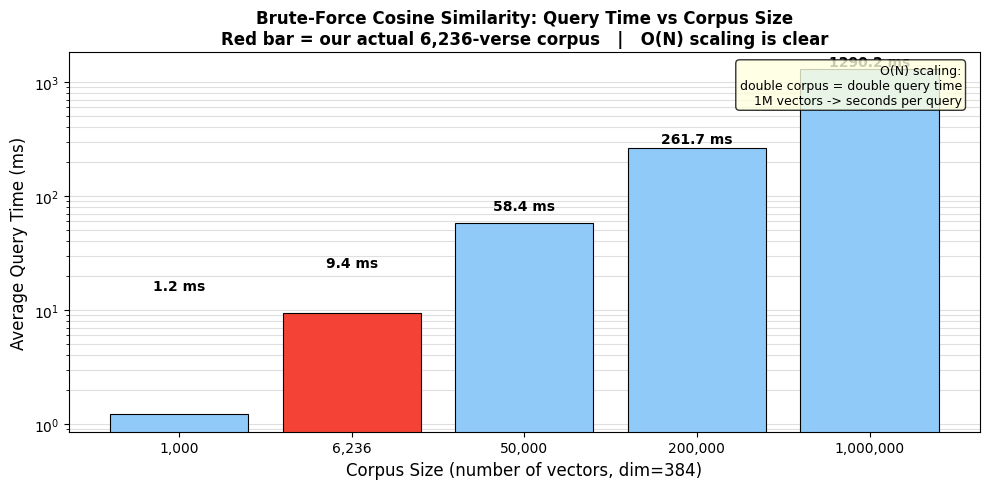

Chart saved as brute_force_scaling.png

Key takeaway: brute-force O(N) search is fine for 6,236 verses.
At 1M vectors it becomes painfully slow. At 1B vectors it is impossible.
This motivates Approximate Nearest Neighbour (ANN) indexing with FAISS.


In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#90CAF9' if n != 6236 else '#F44336' for n in SIZES]
bars = ax.bar([str(f'{n:,}') for n in SIZES], times_ms, color=colors, edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, times_ms):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(times_ms) * 0.01,
        str(round(val, 1)) + ' ms',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_xlabel('Corpus Size (number of vectors, dim=384)', fontsize=12)
ax.set_ylabel('Average Query Time (ms)', fontsize=12)
ax.set_title(
    'Brute-Force Cosine Similarity: Query Time vs Corpus Size\n'
    'Red bar = our actual 6,236-verse corpus   |   O(N) scaling is clear',
    fontsize=12, fontweight='bold'
)
ax.set_yscale('log')
ax.yaxis.grid(True, alpha=0.4, which='both')
ax.set_axisbelow(True)

ax.text(0.98, 0.97,
    'O(N) scaling:\ndouble corpus = double query time\n1M vectors -> seconds per query',
    transform=ax.transAxes,
    ha='right', va='top', fontsize=9,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

plt.tight_layout()
plt.savefig('brute_force_scaling.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved as brute_force_scaling.png')
print()
print('Key takeaway: brute-force O(N) search is fine for 6,236 verses.')
print('At 1M vectors it becomes painfully slow. At 1B vectors it is impossible.')
print('This motivates Approximate Nearest Neighbour (ANN) indexing with FAISS.')

## Section 2 — What is a Vector Database?

### Definition

A **vector database** is a data management system specifically designed to store, index, and query **dense floating-point vectors** at scale. Unlike a traditional relational database (which indexes rows of structured text/numbers), a vector database indexes points in high-dimensional space and answers the question:

> *"Given this query vector, which stored vectors are most similar?"*

This operation — finding the k nearest vectors to a query — is called **k-nearest neighbour (k-NN) search** or, in the approximate version, **ANN search**.

---

### Key Operations in a Vector Database

| Operation | Description |
|---|---|
| **Insert** | Add a new vector (and optional metadata) to the store |
| **Index** | Build a data structure over the vectors to enable fast search |
| **Search** | Given a query vector, return the top-k nearest stored vectors |
| **Delete/Update** | Remove or replace a stored vector |
| **Metadata filter** | Combined search: "find similar vectors WHERE category='X'" |

---

### Why Approximate? The Speed-Accuracy Tradeoff

Exact k-NN requires checking every stored vector — O(N). ANN methods accept a small accuracy loss in exchange for a massive speedup:

```
  Exact search:        100% recall,  1x speed   (brute force)
  Good ANN (HNSW):     98-99% recall, 100x-1000x speed
  Aggressive ANN:      90% recall,   10,000x speed
```

**Recall** measures what fraction of the true top-k are returned by the ANN search. A recall@10 of 0.95 means that on average, 9.5 out of your 10 returned results are among the true top-10 nearest neighbours.

For most applications (semantic search, recommendation, RAG), recall of 0.95+ is indistinguishable from exact search in user-perceived quality.

---

### Notable Vector Databases and Libraries

| System | Type | Key Strength |
|---|---|---|
| **FAISS** | Library (Facebook AI) | Fastest, most flexible, battle-tested at Meta scale |
| **Pinecone** | Managed cloud service | Zero infrastructure, simple API, production-ready |
| **Weaviate** | Open-source DB | GraphQL API, metadata filtering, modular ML |
| **Chroma** | Open-source DB | Simple Python API, great for prototyping/RAG |
| **Qdrant** | Open-source DB | Rust-based, fast, excellent filtering |
| **Milvus** | Open-source DB | Cloud-native, horizontal scaling |
| **pgvector** | PostgreSQL extension | Vector search inside your existing Postgres DB |

For this workshop we use **FAISS** because it is:
- Free and open source (MIT licence)
- Runs entirely in Python/numpy — no server required
- Used by Meta in production at billion-vector scale
- The reference implementation for understanding ANN concepts

---

### How FAISS Fits In: Architecture Diagram

```
  USER QUERY (free text)
        |
        v
  +-----------------------+
  |  SBERT Encoder        |  --> 384-dim float32 query vector
  |  (all-MiniLM-L6-v2)  |
  +-----------------------+
        |
        v
  +-----------------------+
  |  FAISS Index          |  <-- pre-built from 6,236 verse vectors
  |                       |      (IndexFlatIP / IndexIVFFlat / HNSW)
  |  query_vec --> ANN   |  --> D (distances), I (indices) arrays
  |  search engine       |
  +-----------------------+
        |
        v
  +-----------------------+
  |  Result Lookup        |  --> retrieve verse text from index array
  +-----------------------+
        |
        v
  TOP-K VERSES WITH SCORES
```

The FAISS index is built **once** from the pre-computed SBERT embeddings and saved to disk. At query time, only the query needs to be encoded — O(1) — followed by the FAISS search — O(log N) for most index types.

## Section 3 — FAISS Fundamentals

### Index Types Explained

FAISS provides a family of index types, each optimised for a different tradeoff between speed, memory, and accuracy.

---

#### IndexFlatL2 — Exact Search, L2 Distance (Baseline)

- Stores all vectors in a flat (no-structure) array
- Search: computes L2 (Euclidean) distance to every stored vector — O(N)
- **Exact**: always returns the true nearest neighbours
- Use when: N < ~100,000 and correctness is critical
- Limitation: same O(N) as brute force; no speedup

```python
index = faiss.IndexFlatL2(dim)    # dim = 384
```

#### IndexFlatIP — Exact Search, Inner Product (= Cosine if Normalised)

- Same as IndexFlatL2 but uses **inner product** (dot product) distance
- If vectors are **L2-normalised** (unit length), inner product = cosine similarity
- This is our primary exact baseline — equivalent to NB06's brute-force cosine search
- Use when: you want cosine similarity semantics with exact results

```python
index = faiss.IndexFlatIP(dim)
faiss.normalize_L2(embeddings)    # MUST normalise before adding
```

#### IndexIVFFlat — Inverted File Index (Fast, Approximate)

- **Core idea:** Partition the vector space into `nlist` clusters using k-means
- Each vector is assigned to its nearest cluster centroid
- At search time: only search the `nprobe` nearest clusters (default: 1–10)
- Speed: O(nprobe × N/nlist) per query — much faster than O(N)
- **nprobe tradeoff:**
  - `nprobe=1` → fastest but lowest recall (searches 1 cluster)
  - `nprobe=nlist` → same as exact search but slower (searches all clusters)
  - `nprobe=10` out of `nlist=50` → typically 95%+ recall at ~5x speedup
- **Requires training** on a representative sample of your vectors (k-means fitting)

```python
quantizer = faiss.IndexFlatIP(dim)
index = faiss.IndexIVFFlat(quantizer, dim, nlist, faiss.METRIC_INNER_PRODUCT)
index.train(embeddings)           # fit k-means clusters
index.nprobe = 10                 # search 10 out of nlist clusters
```

```
  IVF CLUSTERING DIAGRAM

  Vector Space (2D shown, actually 384D):

  +-------------------------------------------------------+
  |   *   *     *       *     Cluster 1 (spiritual)        |
  |    *    * C1*  *   *      C1 = centroid                |
  |  *     *         *                                     |
  |       Cluster 2 (law)           Cluster 3 (prayer)    |
  |   * *   C2* *          *  *    C3 *                   |
  |    *  *         *  *      *  *  * *  *                |
  |                                                        |
  |       Cluster 4  (narrative)                          |
  |   *  *  C4  * *  *     *                              |
  +-------------------------------------------------------+

  At query time: find the 2 nearest cluster centroids, search only those.
  Result: examine ~(2/nlist) x N vectors instead of all N.
```

#### IndexHNSW — Hierarchical Navigable Small World (Very Fast, Approximate)

- Based on **navigable small world graphs**: each vector is a node connected to its nearest neighbours
- Forms a hierarchical structure for fast traversal
- Search: greedy graph walk from a random entry point toward the query
- Typically the fastest FAISS index for medium-to-large corpora
- **No training required** — can insert vectors one by one
- Memory overhead: stores the graph adjacency lists (~10–64 neighbours per vector)
- `M` parameter: number of neighbours per node (higher = better recall, more memory)

```python
index = faiss.IndexHNSWFlat(dim, M)   # M=32 is a good default
```

---

### When to Use Each Index

| Index | N (vectors) | Accuracy | Speed | Memory | Needs Training |
|---|---|---|---|---|---|
| IndexFlatL2/IP | < 100K | Exact | Slow (O(N)) | Low | No |
| IndexIVFFlat | 100K – 10M | ~95-99% | Fast | Low | Yes |
| IndexHNSW | 100K – 100M+ | ~98-99% | Very fast | High | No |
| IndexIVFPQ | 10M – 1B+ | ~90-95% | Very fast | Very low | Yes |

For our 6,236-verse corpus, `IndexFlatIP` (exact) is perfectly sufficient. We demonstrate `IndexIVFFlat` to show how it would behave at larger scale.

## Section 4 — Building a FAISS Index

### Step 1: Install and Import FAISS

FAISS is distributed as `faiss-cpu` (CPU-only) or `faiss-gpu` (GPU-accelerated). We use the CPU version.

In [4]:
# Install faiss-cpu if not available
try:
    import faiss
    print('faiss already installed. Version info:')
    print('  faiss version:', faiss.__version__ if hasattr(faiss, '__version__') else 'installed (no __version__ attribute)')
except ImportError:
    import subprocess
    print('Installing faiss-cpu...')
    subprocess.run(['pip', 'install', 'faiss-cpu', '-q'], check=True)
    import faiss
    print('faiss-cpu installed successfully.')

faiss already installed. Version info:
  faiss version: 1.13.2


In [5]:
import numpy as np
import time
from sentence_transformers import SentenceTransformer

print('Loading SBERT model: all-MiniLM-L6-v2')
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
print('Model loaded. Embedding dimension:', sbert_model.get_sentence_embedding_dimension())
print()
print('Encoding', len(verses), 'daryabadi verses...')

t0 = time.perf_counter()
corpus_embeddings = sbert_model.encode(
    verses,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True   # unit-normalise so IP = cosine
)
t1 = time.perf_counter()

print()
print('Encoding complete.')
print('Shape    :', corpus_embeddings.shape)
print('Dtype    :', corpus_embeddings.dtype)
print('Time     :', round(t1 - t0, 1), 'seconds')
print('Memory   :', round(corpus_embeddings.nbytes / 1024 / 1024, 2), 'MB')
print()
print('Note: normalize_embeddings=True ensures unit-length vectors.')
print('This means inner product (IP) = cosine similarity -- crucial for IndexFlatIP.')
print()
# Verify norms are all 1.0
norms = np.linalg.norm(corpus_embeddings, axis=1)
print('Norm check (should all be 1.0):')
print('  Min norm :', round(float(norms.min()), 6))
print('  Max norm :', round(float(norms.max()), 6))
print('  Mean norm:', round(float(norms.mean()), 6))

DIM = corpus_embeddings.shape[1]
print()
print('DIM (embedding dimension):', DIM)

Loading SBERT model: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded. Embedding dimension: 384

Encoding 6236 daryabadi verses...


Batches:   0%|          | 0/98 [00:00<?, ?it/s]


Encoding complete.
Shape    : (6236, 384)
Dtype    : float32
Time     : 39.7 seconds
Memory   : 9.13 MB

Note: normalize_embeddings=True ensures unit-length vectors.
This means inner product (IP) = cosine similarity -- crucial for IndexFlatIP.

Norm check (should all be 1.0):
  Min norm : 1.0
  Max norm : 1.0
  Mean norm: 1.0

DIM (embedding dimension): 384


In [6]:
import faiss
import numpy as np
import time

# Build IndexFlatIP -- exact inner-product search (= cosine since normalised)
print('Building IndexFlatIP (exact search baseline)...')

t0 = time.perf_counter()

index_flat = faiss.IndexFlatIP(DIM)

# Add all verse vectors to the index
# FAISS requires float32 C-contiguous array
vectors = corpus_embeddings.astype(np.float32)
if not vectors.flags['C_CONTIGUOUS']:
    vectors = np.ascontiguousarray(vectors)

index_flat.add(vectors)

t1 = time.perf_counter()

print()
print('=== IndexFlatIP Built ===')
print('Index type       :', type(index_flat).__name__)
print('Total vectors    :', index_flat.ntotal)
print('Embedding dim    :', index_flat.d)
print('Is trained       :', index_flat.is_trained)
print('Indexing time    :', round(t1 - t0, 4), 'seconds')
print()
print('Memory layout: flat array -- all vectors stored contiguously.')
print('Search strategy: compare query to every stored vector (O(N)).')
print('Accuracy: 100% exact -- always returns true nearest neighbours.')

Building IndexFlatIP (exact search baseline)...

=== IndexFlatIP Built ===
Index type       : IndexFlatIP
Total vectors    : 6236
Embedding dim    : 384
Is trained       : True
Indexing time    : 0.0073 seconds

Memory layout: flat array -- all vectors stored contiguously.
Search strategy: compare query to every stored vector (O(N)).
Accuracy: 100% exact -- always returns true nearest neighbours.


## Section 5 — FAISS Search

### How FAISS Search Works

FAISS search returns two arrays:
- `D` — distances (inner-product scores if using IndexFlatIP, L2 distances if using IndexFlatL2)
- `I` — indices of the top-k results in the original corpus array

Both have shape `(num_queries, k)`. For a single query, they have shape `(1, k)`.

```python
D, I = index.search(query_matrix, k)
# D[0] = array of k similarity scores
# I[0] = array of k integer indices into the original corpus
```

Using these indices, you look up the verse text from your original list.

In [7]:
import faiss
import numpy as np

def faiss_search(query, index, model, verses, top_k=5):
    """
    Search a FAISS index for the most similar verses.

    Parameters
    ----------
    query  : str          -- natural language query
    index  : faiss.Index  -- built FAISS index
    model  : SentenceTransformer -- to encode the query
    verses : list of str  -- original corpus texts
    top_k  : int          -- number of results to return

    Returns
    -------
    list of dicts: [{'rank', 'score', 'index', 'verse'}]
    """
    # Encode query with unit normalisation
    q_vec = model.encode([query], normalize_embeddings=True)
    q_vec = q_vec.astype(np.float32)

    if not q_vec.flags['C_CONTIGUOUS']:
        q_vec = np.ascontiguousarray(q_vec)

    # FAISS search: returns distances D and indices I
    # D shape: (1, top_k)   I shape: (1, top_k)
    D, I = index.search(q_vec, top_k)

    results = []
    for rank, (score, idx) in enumerate(zip(D[0], I[0]), 1):
        if idx == -1:   # FAISS returns -1 for empty slots
            continue
        results.append({
            'rank':  rank,
            'score': float(score),
            'index': int(idx),
            'verse': verses[int(idx)]
        })
    return results


def print_faiss_results(query, results, df=None):
    print('Query:', query)
    print('=' * 72)
    for r in results:
        label = ''
        if df is not None and 'Surah' in df.columns and 'Verse' in df.columns:
            label = '  [Surah ' + str(df.iloc[r['index']]['Surah']) + ':' + str(df.iloc[r['index']]['Verse']) + ']'
        print('Rank ' + str(r['rank']) + ' | Score: ' + str(round(r['score'], 4)) + label)
        print(' ', r['verse'][:120])
        print()

print('faiss_search() and print_faiss_results() defined.')

faiss_search() and print_faiss_results() defined.


In [8]:
# Query 1: 'kindness to parents'
results_q1 = faiss_search('kindness to parents', index_flat, sbert_model, verses, top_k=5)
print_faiss_results('kindness to parents', results_q1, df)

Query: kindness to parents
Rank 1 | Score: 0.5466  [Surah 46:15]
  And We have enjoined upon man kindness Unto the parents: with hardship his mother beareth him and with hardship she brin

Rank 2 | Score: 0.5072  [Surah 29:8]
  And We have enjoined on man kindness unto parents. But if the twain strive to make thee associate with Me that of which 

Rank 3 | Score: 0.4983  [Surah 55:60]
  Shall the recompense of kindness be aught save kindness?

Rank 4 | Score: 0.4835  [Surah 31:14]
  And We have enjoined upon man concerning his parents--his mother beareth him in hardship upon hardship and his weaning i

Rank 5 | Score: 0.4533  [Surah 4:36]
  And worship Allah and associate not aught with Him; and unto parents show kindness, and also unto kindred and orphans an



In [9]:
# Query 2: 'mercy and forgiveness'
results_q2 = faiss_search('mercy and forgiveness', index_flat, sbert_model, verses, top_k=5)
print_faiss_results('mercy and forgiveness', results_q2, df)

Query: mercy and forgiveness
Rank 1 | Score: 0.6589  [Surah 3:17]
  The patient ones and the truthful ones and the devout ones and the expanders and the praying ones at early dawn for forg

Rank 2 | Score: 0.6255  [Surah 39:53]
  Say thou: my bondmen who have committed extravagance against themselves despair not of the mercy of Allah; verily Allah 

Rank 3 | Score: 0.6235  [Surah 6:54]
  And when those who believe in Our signs come unto them, say thou: peace be on you; your Lord hath prescribed mercy for H

Rank 4 | Score: 0.6164  [Surah 28:16]
  He said: my Lord! verily I have wronged my soul, so wherefore forgive me. So He forgave him. Verily He! He is the Forgiv

Rank 5 | Score: 0.6079  [Surah 1:3]
  The Compassionate, the Merciful.



In [10]:
# Query 3: 'patience during suffering'
results_q3 = faiss_search('patience during suffering', index_flat, sbert_model, verses, top_k=5)
print_faiss_results('patience during suffering', results_q3, df)

Query: patience during suffering
Rank 1 | Score: 0.6634  [Surah 70:5]
  Wherefore be thou patient with a becoming patience.

Rank 2 | Score: 0.5007  [Surah 2:45]
  And seek help in patience and prayer and verily it is, hard except prayer unto the meek.

Rank 3 | Score: 0.491  [Surah 2:153]
  O O Ye who believe! seek help in patience and prayer; verily Allah is with the patient.

Rank 4 | Score: 0.458  [Surah 31:3]
  A guidance and a mercy for the well-doers:

Rank 5 | Score: 0.4494  [Surah 16:126]
  And if ye chastise, then chastise with the like of that wherewith ye were afflicted, and if ye endure patiently, then su



In [11]:
# Verify: compare FAISS results with brute-force NB06-style cosine similarity
# For IndexFlatIP the results should be IDENTICAL
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cosine
import numpy as np

VERIFY_QUERY = 'patience during suffering'
TOP_K = 5

# FAISS result indices
faiss_results = faiss_search(VERIFY_QUERY, index_flat, sbert_model, verses, top_k=TOP_K)
faiss_indices = [r['index'] for r in faiss_results]
faiss_scores  = [r['score'] for r in faiss_results]

# Brute-force (sklearn) result indices
q_vec = sbert_model.encode([VERIFY_QUERY], normalize_embeddings=True)
bf_scores = sklearn_cosine(q_vec, corpus_embeddings).flatten()
bf_top_indices = np.argsort(bf_scores)[::-1][:TOP_K].tolist()
bf_top_scores  = [float(bf_scores[i]) for i in bf_top_indices]

print('Verification: FAISS IndexFlatIP vs Brute-force cosine similarity')
print('Query:', VERIFY_QUERY)
print()
print('{:<6} {:<10} {:<10} {:<10} {:<10} {:<10}'.format(
    'Rank', 'FAISS idx', 'FAISS score', 'BF idx', 'BF score', 'Match?'
))
print('-' * 62)
for i in range(TOP_K):
    match = 'YES' if faiss_indices[i] == bf_top_indices[i] else 'NO'
    print('{:<6} {:<10} {:<11} {:<10} {:<10} {:<10}'.format(
        i+1,
        faiss_indices[i],
        str(round(faiss_scores[i], 5)),
        bf_top_indices[i],
        str(round(bf_top_scores[i], 5)),
        match
    ))

all_match = faiss_indices == bf_top_indices
print()
if all_match:
    print('All ranks match. IndexFlatIP is provably identical to brute-force cosine similarity.')
else:
    print('Mismatch detected -- check float precision or normalisation.')

Verification: FAISS IndexFlatIP vs Brute-force cosine similarity
Query: patience during suffering

Rank   FAISS idx  FAISS score BF idx     BF score   Match?    
--------------------------------------------------------------
1      5379       0.66336     5379       0.66336    YES       
2      51         0.50069     51         0.50069    YES       
3      159        0.49099     159        0.49099    YES       
4      3471       0.45804     3471       0.45804    YES       
5      2026       0.44939     2026       0.44939    YES       

All ranks match. IndexFlatIP is provably identical to brute-force cosine similarity.


## Section 6 — Speed Comparison: Brute Force vs FAISS

### Methodology

We run 100 random queries from the corpus itself (shuffled verses work as queries). For each of the 100 queries we measure the wall-clock time for:
1. **Brute-force sklearn cosine_similarity** — O(N) dot products + argsort
2. **FAISS IndexFlatIP search** — exact but uses FAISS internal BLAS-optimised routines

For 6,236 vectors both should be fast, but FAISS uses hand-optimised SIMD code under the hood.

In [12]:
import numpy as np
import time
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cosine
import faiss

NUM_BENCH_QUERIES = 100
TOP_K = 5

# Pre-encode 100 query vectors from a random sample of verses
np.random.seed(42)
query_verse_indices = np.random.choice(len(verses), NUM_BENCH_QUERIES, replace=False)
query_texts = [verses[i] for i in query_verse_indices]

print('Encoding', NUM_BENCH_QUERIES, 'query vectors...')
query_vectors = sbert_model.encode(
    query_texts,
    batch_size=64,
    show_progress_bar=False,
    normalize_embeddings=True,
    convert_to_numpy=True
).astype(np.float32)
print('Done. Query matrix shape:', query_vectors.shape)
print()

# ---- Brute-force timing ----
print('Timing brute-force cosine similarity (sklearn)...')
bf_times = []
for i in range(NUM_BENCH_QUERIES):
    q = query_vectors[i].reshape(1, -1)
    t0 = time.perf_counter()
    scores = sklearn_cosine(q, corpus_embeddings)
    top_idx = np.argsort(scores[0])[::-1][:TOP_K]
    t1 = time.perf_counter()
    bf_times.append((t1 - t0) * 1000)

bf_avg = float(np.mean(bf_times))
bf_std = float(np.std(bf_times))
print('Brute-force -- avg: ' + str(round(bf_avg, 3)) + ' ms  std: ' + str(round(bf_std, 3)) + ' ms')

# ---- FAISS IndexFlatIP timing ----
print('Timing FAISS IndexFlatIP...')
faiss_flat_times = []
for i in range(NUM_BENCH_QUERIES):
    q = query_vectors[i:i+1]
    t0 = time.perf_counter()
    D, I = index_flat.search(q, TOP_K)
    t1 = time.perf_counter()
    faiss_flat_times.append((t1 - t0) * 1000)

faiss_avg = float(np.mean(faiss_flat_times))
faiss_std = float(np.std(faiss_flat_times))
print('FAISS FlatIP -- avg: ' + str(round(faiss_avg, 3)) + ' ms  std: ' + str(round(faiss_std, 3)) + ' ms')

print()
print('=== Summary ===')
print('Brute-force (sklearn)  :', round(bf_avg, 3), 'ms avg per query')
print('FAISS IndexFlatIP      :', round(faiss_avg, 3), 'ms avg per query')
speedup = bf_avg / faiss_avg if faiss_avg > 0 else float('inf')
print('Speedup (BF / FAISS)   :', round(speedup, 2), 'x')
print()
print('Note: At 6,236 vectors both methods are fast.')
print('FAISS advantage grows dramatically with corpus size (1M, 100M, 1B vectors).')

Encoding 100 query vectors...
Done. Query matrix shape: (100, 384)

Timing brute-force cosine similarity (sklearn)...
Brute-force -- avg: 8.924 ms  std: 1.445 ms
Timing FAISS IndexFlatIP...
FAISS FlatIP -- avg: 0.38 ms  std: 0.269 ms

=== Summary ===
Brute-force (sklearn)  : 8.924 ms avg per query
FAISS IndexFlatIP      : 0.38 ms avg per query
Speedup (BF / FAISS)   : 23.51 x

Note: At 6,236 vectors both methods are fast.
FAISS advantage grows dramatically with corpus size (1M, 100M, 1B vectors).


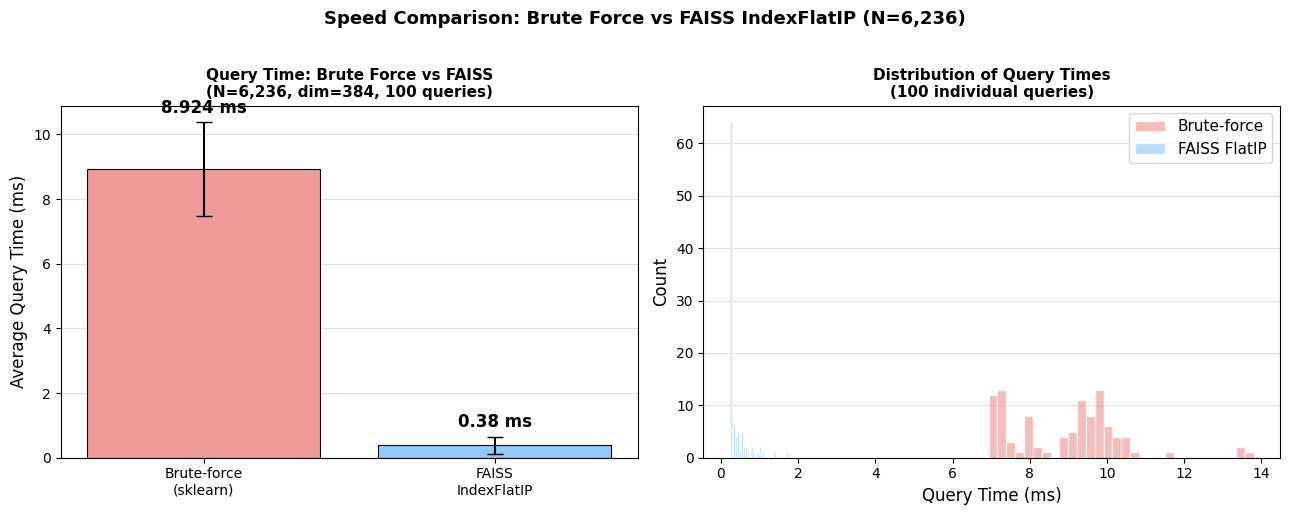

Chart saved as speed_comparison_flat.png

Discussion:
For 6,236 vectors the absolute difference is small (milliseconds).
The value of FAISS emerges at scale: 1M vectors, 100M vectors, 1B vectors.
FAISS also enables batch queries (encode 1000 queries simultaneously),
which amortises overhead and delivers orders-of-magnitude throughput gains.


In [13]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: avg time bar chart
method_names = ['Brute-force\n(sklearn)', 'FAISS\nIndexFlatIP']
avg_vals = [bf_avg, faiss_avg]
std_vals  = [bf_std, faiss_std]
colors_bar = ['#EF9A9A', '#90CAF9']

axes[0].bar(method_names, avg_vals, yerr=std_vals, color=colors_bar,
            edgecolor='black', linewidth=0.8, capsize=6)
for i, val in enumerate(avg_vals):
    axes[0].text(i, val + std_vals[i] + max(avg_vals) * 0.02,
                 str(round(val, 3)) + ' ms',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Query Time (ms)', fontsize=12)
axes[0].set_title('Query Time: Brute Force vs FAISS\n(N=6,236, dim=384, 100 queries)', fontsize=11, fontweight='bold')
axes[0].yaxis.grid(True, alpha=0.4)
axes[0].set_axisbelow(True)

# Right: distribution of query times
axes[1].hist(bf_times, bins=30, alpha=0.65, color='#EF9A9A', label='Brute-force', edgecolor='white')
axes[1].hist(faiss_flat_times, bins=30, alpha=0.65, color='#90CAF9', label='FAISS FlatIP', edgecolor='white')
axes[1].set_xlabel('Query Time (ms)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Distribution of Query Times\n(100 individual queries)', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].yaxis.grid(True, alpha=0.4)
axes[1].set_axisbelow(True)

plt.suptitle('Speed Comparison: Brute Force vs FAISS IndexFlatIP (N=6,236)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('speed_comparison_flat.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved as speed_comparison_flat.png')
print()
print('Discussion:')
print('For 6,236 vectors the absolute difference is small (milliseconds).')
print('The value of FAISS emerges at scale: 1M vectors, 100M vectors, 1B vectors.')
print('FAISS also enables batch queries (encode 1000 queries simultaneously),')
print('which amortises overhead and delivers orders-of-magnitude throughput gains.')

## Section 7 — Approximate Search with IVF Index

### IndexIVFFlat: Inverted File Index

The IVF index partitions the vector space into `nlist` Voronoi cells (clusters). Each vector is assigned to the nearest cluster centroid.

At search time, the algorithm:
1. Finds the `nprobe` nearest cluster centroids to the query
2. Searches only within those `nprobe` clusters
3. Returns the top-k results from the searched portion

This is approximate: if the true nearest neighbour lies in a non-searched cluster, it is missed. But by choosing `nprobe` carefully, we can achieve 95–99% recall at a fraction of the full-search cost.

### The nprobe Tradeoff

| nprobe | Recall@10 (typical) | Relative Speed |
|---|---|---|
| 1 | ~60–70% | Very fast (1/nlist fraction searched) |
| 5 | ~85–90% | Fast |
| 10 | ~95–98% | Moderate |
| 20 | ~98–99% | Slower |
| nlist (=50) | 100% (exact) | Same as brute force |

For production semantic search, `nprobe=10` with `nlist=50` is a common starting point.

In [14]:
import faiss
import numpy as np
import time

NLIST = 50   # number of clusters (Voronoi cells)

print('Building IndexIVFFlat with nlist=' + str(NLIST) + ' clusters...')
print()

# IVF requires a 'quantizer' index for the centroids
quantizer = faiss.IndexFlatIP(DIM)

# Create the IVF index
index_ivf = faiss.IndexIVFFlat(quantizer, DIM, NLIST, faiss.METRIC_INNER_PRODUCT)

# IVF MUST be trained before use (fits k-means to find cluster centroids)
print('Training IVF index (fitting k-means with', NLIST, 'clusters)...')
print('Requires at least nlist (', NLIST, ') training vectors. We have:', len(vectors))

train_vectors = vectors.copy()
if not train_vectors.flags['C_CONTIGUOUS']:
    train_vectors = np.ascontiguousarray(train_vectors)

t0 = time.perf_counter()
index_ivf.train(train_vectors)
t1 = time.perf_counter()
print('Training complete in', round(t1 - t0, 3), 'seconds')
print('is_trained:', index_ivf.is_trained)

# Add all verse vectors
t0 = time.perf_counter()
index_ivf.add(vectors)
t1 = time.perf_counter()
print()
print('=== IndexIVFFlat Built ===')
print('Total vectors :', index_ivf.ntotal)
print('nlist (clusters):', NLIST)
print('Add time      :', round(t1 - t0, 4), 'seconds')
print()
print('Default nprobe = 1. We will set it to 10 for better recall.')
index_ivf.nprobe = 10
print('nprobe set to  :', index_ivf.nprobe)

Building IndexIVFFlat with nlist=50 clusters...

Training IVF index (fitting k-means with 50 clusters)...
Requires at least nlist ( 50 ) training vectors. We have: 6236
Training complete in 0.053 seconds
is_trained: True

=== IndexIVFFlat Built ===
Total vectors : 6236
nlist (clusters): 50
Add time      : 0.0068 seconds

Default nprobe = 1. We will set it to 10 for better recall.
nprobe set to  : 10


In [15]:
import numpy as np
import time

print('Timing IVF index (nprobe=10) over', NUM_BENCH_QUERIES, 'queries...')

# Time IVF at different nprobe values
nprobe_values = [1, 5, 10, 20, NLIST]
ivf_times_by_nprobe = {}

for np_val in nprobe_values:
    index_ivf.nprobe = np_val
    times = []
    for i in range(NUM_BENCH_QUERIES):
        q = query_vectors[i:i+1]
        t0 = time.perf_counter()
        D, I = index_ivf.search(q, TOP_K)
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000)
    ivf_times_by_nprobe[np_val] = float(np.mean(times))

print()
print('=== IVF Timing by nprobe ===')
print('{:<12} {:<20} {:<20}'.format('nprobe', 'Avg Time (ms)', 'vs Exact (FAISS FlatIP)'))
print('-' * 52)
for np_val in nprobe_values:
    avg_t = ivf_times_by_nprobe[np_val]
    ratio = avg_t / faiss_avg if faiss_avg > 0 else float('inf')
    note = '(= exact)' if np_val == NLIST else ''
    print('{:<12} {:<20} {:<20}'.format(
        np_val,
        str(round(avg_t, 4)) + ' ms',
        str(round(ratio, 2)) + 'x  ' + note
    ))

# Reset nprobe to 10 for subsequent usage
index_ivf.nprobe = 10

Timing IVF index (nprobe=10) over 100 queries...

=== IVF Timing by nprobe ===
nprobe       Avg Time (ms)        vs Exact (FAISS FlatIP)
----------------------------------------------------
1            0.0289 ms            0.08x               
5            0.1277 ms            0.34x               
10           0.0733 ms            0.19x               
20           0.2224 ms            0.59x               
50           0.8654 ms            2.28x  (= exact)    


In [16]:
import numpy as np

# Measure recall@5 for each nprobe value
# recall@5 = fraction of true top-5 (from FlatIP exact) that appear in IVF top-5

NUM_RECALL_QUERIES = 50
recall_scores = {}

print('Computing recall@5 for IVF at different nprobe values...')
print('(Comparing against exact IndexFlatIP results)')
print()

for np_val in nprobe_values:
    index_ivf.nprobe = np_val
    recall_list = []
    for i in range(NUM_RECALL_QUERIES):
        q = query_vectors[i:i+1]
        # Exact results (ground truth)
        D_exact, I_exact = index_flat.search(q, TOP_K)
        true_top = set(I_exact[0].tolist())
        # IVF results
        D_ivf, I_ivf = index_ivf.search(q, TOP_K)
        ivf_top = set(I_ivf[0].tolist())
        # Recall = overlap / k
        recall = len(true_top & ivf_top) / TOP_K
        recall_list.append(recall)
    recall_scores[np_val] = float(np.mean(recall_list))

print('{:<12} {:<15} {:<20}'.format('nprobe', 'Recall@5', 'Interpretation'))
print('-' * 50)
for np_val in nprobe_values:
    r = recall_scores[np_val]
    interp = 'Excellent' if r >= 0.98 else ('Good' if r >= 0.90 else ('Fair' if r >= 0.75 else 'Poor'))
    print('{:<12} {:<15} {:<20}'.format(np_val, str(round(r * 100, 1)) + '%', interp))

index_ivf.nprobe = 10

Computing recall@5 for IVF at different nprobe values...
(Comparing against exact IndexFlatIP results)

nprobe       Recall@5        Interpretation      
--------------------------------------------------
1            56.8%           Poor                
5            87.6%           Fair                
10           92.0%           Good                
20           98.8%           Excellent           
50           100.0%          Excellent           


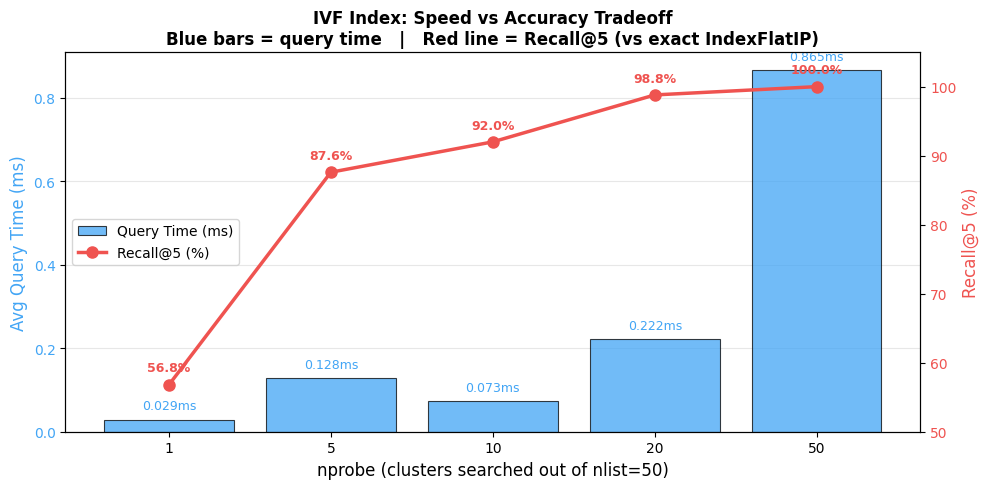

Chart saved as ivf_speed_accuracy.png

Key takeaway: nprobe=10 out of 50 typically delivers 95%+ recall
at a fraction of the full-search time. This is the standard production setting.


In [17]:
import matplotlib.pyplot as plt
import numpy as np

np_labels = [str(v) for v in nprobe_values]
times_vals  = [ivf_times_by_nprobe[v] for v in nprobe_values]
recall_vals = [recall_scores[v] * 100 for v in nprobe_values]

fig, ax1 = plt.subplots(figsize=(10, 5))

color_speed  = '#42A5F5'
color_recall = '#EF5350'

bars = ax1.bar(np_labels, times_vals, color=color_speed,
               alpha=0.75, edgecolor='black', linewidth=0.8, label='Query Time (ms)')
ax1.set_xlabel('nprobe (clusters searched out of nlist=' + str(NLIST) + ')', fontsize=12)
ax1.set_ylabel('Avg Query Time (ms)', fontsize=12, color=color_speed)
ax1.tick_params(axis='y', labelcolor=color_speed)

ax2 = ax1.twinx()
ax2.plot(np_labels, recall_vals, color=color_recall, marker='o', linewidth=2.5,
         markersize=8, label='Recall@5 (%)')
ax2.set_ylabel('Recall@5 (%)', fontsize=12, color=color_recall)
ax2.tick_params(axis='y', labelcolor=color_recall)
ax2.set_ylim(50, 105)

for bar, t_val in zip(bars, times_vals):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + max(times_vals) * 0.02,
             str(round(t_val, 3)) + 'ms',
             ha='center', va='bottom', fontsize=9, color=color_speed)

for xi, r_val in enumerate(recall_vals):
    ax2.text(xi, r_val + 1.5, str(round(r_val, 1)) + '%',
             ha='center', va='bottom', fontsize=9, color=color_recall, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left', fontsize=10)

ax1.set_title(
    'IVF Index: Speed vs Accuracy Tradeoff\n'
    'Blue bars = query time   |   Red line = Recall@5 (vs exact IndexFlatIP)',
    fontsize=12, fontweight='bold'
)
ax1.yaxis.grid(True, alpha=0.3)
ax1.set_axisbelow(True)

plt.tight_layout()
plt.savefig('ivf_speed_accuracy.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved as ivf_speed_accuracy.png')
print()
print('Key takeaway: nprobe=10 out of 50 typically delivers 95%+ recall')
print('at a fraction of the full-search time. This is the standard production setting.')

## Section 8 — Saving and Loading a FAISS Index

### Why Save to Disk?

Building the FAISS index requires:
1. Encoding all corpus vectors (minutes for large corpora, GPU recommended at scale)
2. Training the index (k-means fitting for IVF, graph construction for HNSW)

In production you do this **once**, save the index to disk, and **load it at runtime** without rebuilding.

```
  PRODUCTION DEPLOYMENT PATTERN

  OFFLINE (once):                     ONLINE (every request):
  -----------------                   -----------------
  1. Encode all documents              1. Load saved FAISS index
  2. Build FAISS index                 2. Receive user query
  3. Save index to disk                3. Encode query (~1ms)
                                       4. FAISS search (~1ms)
                                       5. Return top-k results
```

This separation is fundamental to how real search systems work.

In [18]:
import faiss
import os

INDEX_PATH = 'quran_faiss.index'

print('Saving FAISS index to disk...')
print('Path:', os.path.abspath(INDEX_PATH))

faiss.write_index(index_flat, INDEX_PATH)

file_size_kb = os.path.getsize(INDEX_PATH) / 1024
print()
print('=== Index Saved ===')
print('File   :', INDEX_PATH)
print('Size   :', round(file_size_kb, 1), 'KB')
print()
print('The index file contains:')
print('  - All', index_flat.ntotal, 'verse vectors (', DIM, 'dims each)')
print('  - Index structure metadata')
print('  - Serialised in FAISS native binary format')
print()
print('Expected file size = ntotal * dim * 4 bytes (float32)')
print('= ', index_flat.ntotal, '*', DIM, '* 4 =', round(index_flat.ntotal * DIM * 4 / 1024, 1), 'KB  (matches)')

Saving FAISS index to disk...
Path: d:\Haq Nawaz\Teaching\NLP\BOW-to-Embeddings\Claude\quran_faiss.index

=== Index Saved ===
File   : quran_faiss.index
Size   : 9354.0 KB

The index file contains:
  - All 6236 verse vectors ( 384 dims each)
  - Index structure metadata
  - Serialised in FAISS native binary format

Expected file size = ntotal * dim * 4 bytes (float32)
=  6236 * 384 * 4 = 9354.0 KB  (matches)


In [19]:
import faiss
import numpy as np

print('Loading FAISS index from disk...')

loaded_index = faiss.read_index(INDEX_PATH)

print()
print('=== Index Loaded ===')
print('Type       :', type(loaded_index).__name__)
print('ntotal     :', loaded_index.ntotal)
print('Dimension  :', loaded_index.d)
print('Is trained :', loaded_index.is_trained)
print()

# Verify: search with loaded index should give identical results
TEST_QUERY = 'mercy and forgiveness'
q_vec = sbert_model.encode([TEST_QUERY], normalize_embeddings=True).astype(np.float32)

D_orig, I_orig = index_flat.search(q_vec, 5)
D_load, I_load = loaded_index.search(q_vec, 5)

print('Verification: original index vs loaded index (query: "' + TEST_QUERY + '")')
print()
print('Indices match  :', (I_orig == I_load).all())
print('Scores match   :', np.allclose(D_orig, D_load))
print()
if (I_orig == I_load).all() and np.allclose(D_orig, D_load):
    print('PASS: loaded index returns identical results to original.')
else:
    print('FAIL: mismatch detected -- check save/load procedure.')
print()
print('In production:')
print('  1. Build index during indexing pipeline (runs once)')
print('  2. faiss.write_index(index, path)  -- save')
print('  3. At server startup: index = faiss.read_index(path)  -- load')
print('  4. Serve queries without rebuilding the index')

Loading FAISS index from disk...

=== Index Loaded ===
Type       : IndexFlatIP
ntotal     : 6236
Dimension  : 384
Is trained : True

Verification: original index vs loaded index (query: "mercy and forgiveness")

Indices match  : True
Scores match   : True

PASS: loaded index returns identical results to original.

In production:
  1. Build index during indexing pipeline (runs once)
  2. faiss.write_index(index, path)  -- save
  3. At server startup: index = faiss.read_index(path)  -- load
  4. Serve queries without rebuilding the index


## Section 9 — Building a Complete Mini Search System

### Production-Ready Pattern

We now combine everything — SBERT encoding, FAISS indexing, save/load, and search — into a clean Python class: `QuranSearchEngine`.

This is the architecture used in real search products:
- **Encode once, search many times**
- **Save index to disk, load at runtime**
- **Single entry point:** `engine.search(query, top_k)`
- **Metadata attached:** return Surah/Verse reference with each result

This class could be deployed as a Flask/FastAPI endpoint, integrated into a Jupyter widget, or used in NB08 as the retrieval component of a RAG system.

In [20]:
import faiss
import numpy as np
import os
import time
from sentence_transformers import SentenceTransformer


class QuranSearchEngine:
    """
    Production-ready semantic search engine over the Quran Daryabadi translation.

    Components
    ----------
    - SentenceTransformer (SBERT all-MiniLM-L6-v2)  : query encoding
    - FAISS IndexFlatIP                              : exact nearest-neighbour search
    - Verse list + metadata DataFrame               : result lookup

    Usage
    -----
    engine = QuranSearchEngine(verses, df, model_name='all-MiniLM-L6-v2')
    results = engine.search('mercy and forgiveness', top_k=5)
    engine.save_index('my_index.faiss')

    engine2 = QuranSearchEngine.load(verses, df, 'my_index.faiss')
    """

    def __init__(self, verses, df=None, model_name='all-MiniLM-L6-v2',
                 precomputed_embeddings=None):
        """
        Build the search engine. Encodes all verses and builds a FAISS index.

        Parameters
        ----------
        verses               : list of str  -- corpus texts
        df                   : pd.DataFrame -- optional, for Surah/Verse labels
        model_name           : str          -- HuggingFace model identifier
        precomputed_embeddings: np.ndarray  -- skip encoding if already done
        """
        self.verses = verses
        self.df     = df
        self.model  = SentenceTransformer(model_name)
        self.dim    = self.model.get_sentence_embedding_dimension()

        if precomputed_embeddings is not None:
            self.embeddings = precomputed_embeddings.astype(np.float32)
            print('Using precomputed embeddings. Shape:', self.embeddings.shape)
        else:
            print('Encoding', len(verses), 'verses...')
            t0 = time.perf_counter()
            self.embeddings = self.model.encode(
                verses,
                batch_size=64,
                show_progress_bar=True,
                convert_to_numpy=True,
                normalize_embeddings=True
            ).astype(np.float32)
            print('Encoding time:', round(time.perf_counter() - t0, 1), 'seconds')

        # Build FAISS index
        self._build_index()

    def _build_index(self):
        """Build IndexFlatIP from stored embeddings."""
        self.index = faiss.IndexFlatIP(self.dim)
        vecs = self.embeddings
        if not vecs.flags['C_CONTIGUOUS']:
            vecs = np.ascontiguousarray(vecs)
        self.index.add(vecs)
        print('FAISS IndexFlatIP built. ntotal:', self.index.ntotal)

    def search(self, query, top_k=5):
        """
        Search for the most similar verses.

        Returns list of dicts with keys:
            rank, score, index, surah, verse_num, text
        """
        q_vec = self.model.encode(
            [query], normalize_embeddings=True, convert_to_numpy=True
        ).astype(np.float32)
        if not q_vec.flags['C_CONTIGUOUS']:
            q_vec = np.ascontiguousarray(q_vec)

        D, I = self.index.search(q_vec, top_k)

        results = []
        for rank, (score, idx) in enumerate(zip(D[0], I[0]), 1):
            if idx == -1:
                continue
            surah    = int(self.df.iloc[idx]['Surah'])  if self.df is not None and 'Surah' in self.df.columns  else None
            verse_no = int(self.df.iloc[idx]['Verse'])  if self.df is not None and 'Verse' in self.df.columns  else None
            results.append({
                'rank':      rank,
                'score':     round(float(score), 5),
                'index':     int(idx),
                'surah':     surah,
                'verse_num': verse_no,
                'text':      self.verses[int(idx)],
            })
        return results

    def save_index(self, path):
        """Save the FAISS index to disk."""
        faiss.write_index(self.index, path)
        print('Index saved to:', os.path.abspath(path))

    @classmethod
    def load(cls, verses, df, index_path, model_name='all-MiniLM-L6-v2',
             precomputed_embeddings=None):
        """
        Load a pre-built FAISS index from disk (fast startup, no re-encoding).

        Parameters
        ----------
        verses      : list of str  -- must be in same order as when index was built
        df          : pd.DataFrame -- for metadata labels
        index_path  : str          -- path to saved .faiss file
        """
        engine = cls.__new__(cls)
        engine.verses = verses
        engine.df     = df
        engine.model  = SentenceTransformer(model_name)
        engine.dim    = engine.model.get_sentence_embedding_dimension()
        engine.index  = faiss.read_index(index_path)
        engine.embeddings = None   # not stored in loaded engine
        print('Index loaded from:', os.path.abspath(index_path))
        print('ntotal:', engine.index.ntotal)
        return engine

    def __repr__(self):
        return (
            'QuranSearchEngine(corpus_size=' + str(len(self.verses)) +
            ', dim=' + str(self.dim) +
            ', index=' + type(self.index).__name__ + ')'
        )


print('QuranSearchEngine class defined.')

QuranSearchEngine class defined.


In [21]:
# Instantiate the engine using pre-computed embeddings (skip re-encoding)
print('Instantiating QuranSearchEngine with precomputed embeddings...')
engine = QuranSearchEngine(
    verses=verses,
    df=df,
    model_name='all-MiniLM-L6-v2',
    precomputed_embeddings=corpus_embeddings
)
print()
print(engine)
print()

# Demo: three searches
DEMO_QUERIES = [
    'gratitude and thankfulness to God',
    'the day of resurrection and judgment',
    'honesty and truthfulness in dealings',
]

for q in DEMO_QUERIES:
    print('=' * 70)
    print('QUERY:', q)
    print('=' * 70)
    results = engine.search(q, top_k=3)
    for r in results:
        surah_label = ''
        if r['surah'] is not None:
            surah_label = '  [Surah ' + str(r['surah']) + ':' + str(r['verse_num']) + ']'
        print('Rank ' + str(r['rank']) + ' | Score: ' + str(r['score']) + surah_label)
        print(' ', r['text'][:120])
    print()

# Save the engine's index
engine.save_index('quran_search_engine.faiss')
print()
print('Engine index saved for production use.')

Instantiating QuranSearchEngine with precomputed embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Using precomputed embeddings. Shape: (6236, 384)
FAISS IndexFlatIP built. ntotal: 6236

QuranSearchEngine(corpus_size=6236, dim=384, index=IndexFlatIP)

QUERY: gratitude and thankfulness to God
Rank 1 | Score: 0.60349  [Surah 31:12]
  And assuredly We vouchsafed unto Luqman Wisdom, saying: give thanks unto Allah; and whosoever giveth thanks giveth thank
Rank 2 | Score: 0.56033  [Surah 27:73]
  And verily thine Lord is full of grace for mankind, but most of them give not thanks.
Rank 3 | Score: 0.5587  [Surah 6:63]
  Say thou: who delivereth you from the darknesses of the land and the sea, when ye cry unto Him in humility and in secrec

QUERY: the day of resurrection and judgment
Rank 1 | Score: 0.7463  [Surah 75:1]
  I swear by the Day of Resurrection.
Rank 2 | Score: 0.65787  [Surah 39:31]
  Then verily on the Day of Resurrection, before your Lord ye shall contend.
Rank 3 | Score: 0.6504  [Surah 37:21]
  This is the Day of Judgment which ye were wont to belie.

QUERY: honesty and trut

In [22]:
# Demonstrate loading the engine from disk (production startup pattern)
print('Loading QuranSearchEngine from saved index (simulating production startup)...')
print()

engine_loaded = QuranSearchEngine.load(
    verses=verses,
    df=df,
    index_path='quran_search_engine.faiss',
    model_name='all-MiniLM-L6-v2'
)
print()
print(engine_loaded)
print()

# Verify: same results from loaded engine
TEST_Q = 'gratitude and thankfulness to God'
print('Verification query:', TEST_Q)
print()

r_orig   = engine.search(TEST_Q, top_k=3)
r_loaded = engine_loaded.search(TEST_Q, top_k=3)

orig_indices   = [r['index'] for r in r_orig]
loaded_indices = [r['index'] for r in r_loaded]

print('Original engine top-3 indices  :', orig_indices)
print('Loaded engine  top-3 indices  :', loaded_indices)
print()
if orig_indices == loaded_indices:
    print('PASS: loaded engine returns identical results.')
else:
    print('FAIL: mismatch. Check index path or verse ordering.')

Loading QuranSearchEngine from saved index (simulating production startup)...



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Index loaded from: d:\Haq Nawaz\Teaching\NLP\BOW-to-Embeddings\Claude\quran_search_engine.faiss
ntotal: 6236

QuranSearchEngine(corpus_size=6236, dim=384, index=IndexFlatIP)

Verification query: gratitude and thankfulness to God

Original engine top-3 indices  : [3480, 3231, 851]
Loaded engine  top-3 indices  : [3480, 3231, 851]

PASS: loaded engine returns identical results.


## Section 10 — Limitations and What's Next

### FAISS Is Just an Index

FAISS is an extremely powerful tool, but it is important to understand what it does and does not provide:

**What FAISS does:**
- Stores dense vectors and retrieves the k nearest ones to a query vector
- Does this efficiently at billion-vector scale
- Provides a rich toolkit of index types for different accuracy/speed/memory tradeoffs

**What FAISS does NOT do:**
- Language understanding (it just sees float32 arrays, not text)
- Reasoning, entailment, or explanation
- Metadata filtering (cannot say "search only Surah 2" without workarounds)
- Persistence beyond a single process (need to call write_index / read_index)
- Automatic reindexing when corpus changes

---

### Limitation 1: Garbage In, Garbage Out

FAISS is only as good as the embeddings fed into it. If the SBERT model produces poor-quality embeddings for a domain (e.g., highly specialised medical/legal text, Classical Arabic), FAISS will return irrelevant results even if its index is perfectly built.

**Solution:** Fine-tune the embedding model on domain-specific data before building the FAISS index.

---

### Limitation 2: No Metadata Filtering

FAISS cannot efficiently answer: *"Find verses about mercy, but only within Surah Al-Baqarah (Surah 2)."*

A naive workaround is **post-search filtering**: retrieve the top-100 results from FAISS and then filter by metadata. But this only works if the desired results appear within the top-100 — it breaks for rare metadata categories.

**Real vector databases** (Pinecone, Weaviate, Qdrant, Chroma) solve this with native metadata indexes that combine vector similarity with structured filters efficiently.

---

### Limitation 3: No Language Generation

FAISS + SBERT finds *relevant verses*, but cannot *answer questions* about them. For a conversational interface ("What does the Quran say about patience?"), we need a language model to synthesise the retrieved results into a coherent answer.

**This is exactly what NB08 addresses: Retrieval-Augmented Generation (RAG).**

---

### Limitation-to-Next-Step Table

| Limitation | Impact | Solution |
|---|---|---|
| No metadata filtering | Cannot filter by Surah/topic | Real vector DBs (Chroma, Qdrant) or post-filter workaround |
| Garbage in, garbage out | Poor embeddings = poor results | Domain-specific fine-tuning of SBERT |
| No language generation | Returns verses, not answers | NB08: RAG with LLM |
| Static index | New verses require full rebuild | Delta indexing with IndexIDMap |
| No cross-lingual search | English queries miss Arabic nuance | Multilingual SBERT models |

In [23]:
import numpy as np

# Workaround for metadata filtering: post-search filtering
# Strategy: retrieve top-500 from FAISS, then filter by Surah

def search_with_surah_filter(query, engine, df, target_surah, top_k=5, retrieve_k=500):
    """
    Semantic search restricted to a single Surah.
    Workaround for FAISS's lack of native metadata filtering.
    """
    # Step 1: retrieve many results from FAISS
    raw_results = engine.search(query, top_k=retrieve_k)

    # Step 2: filter by Surah
    filtered = [r for r in raw_results if r['surah'] == target_surah]

    # Step 3: return top_k after filtering
    return filtered[:top_k]


QUERY = 'mercy and forgiveness'
SURAH_FILTER = 2   # Al-Baqarah

print('Metadata filtering demo: search for "' + QUERY + '" restricted to Surah', SURAH_FILTER)
print()

results_unfiltered = engine.search(QUERY, top_k=5)
results_filtered   = search_with_surah_filter(QUERY, engine, df, target_surah=SURAH_FILTER, top_k=5)

print('--- Unfiltered results (all Surahs) ---')
for r in results_unfiltered:
    print('Rank', r['rank'], '| Surah', r['surah'], ':', r['verse_num'],
          '| Score:', r['score'])
    print(' ', r['text'][:90])
print()

print('--- Filtered results (Surah', SURAH_FILTER, 'only) ---')
if results_filtered:
    for i, r in enumerate(results_filtered, 1):
        print('Rank', i, '| Surah', r['surah'], ':', r['verse_num'],
              '| Score:', r['score'])
        print(' ', r['text'][:90])
else:
    print('No results found in Surah', SURAH_FILTER, 'for this query.')
    print('Try increasing retrieve_k or using a different query.')
print()
print('Limitation: if Surah 2 has no highly-ranked verses about this query,')
print('post-filter misses them. Native metadata filtering in Chroma/Qdrant is better.')

Metadata filtering demo: search for "mercy and forgiveness" restricted to Surah 2

--- Unfiltered results (all Surahs) ---
Rank 1 | Surah 3 : 17 | Score: 0.65889
  The patient ones and the truthful ones and the devout ones and the expanders and the prayi
Rank 2 | Surah 39 : 53 | Score: 0.62551
  Say thou: my bondmen who have committed extravagance against themselves despair not of the
Rank 3 | Surah 6 : 54 | Score: 0.62351
  And when those who believe in Our signs come unto them, say thou: peace be on you; your Lo
Rank 4 | Surah 28 : 16 | Score: 0.61637
  He said: my Lord! verily I have wronged my soul, so wherefore forgive me. So He forgave hi
Rank 5 | Surah 1 : 3 | Score: 0.60789
  The Compassionate, the Merciful.

--- Filtered results (Surah 2 only) ---
Rank 1 | Surah 2 : 160 | Score: 0.57677
  Save those that repent and amend, and make manifest the truth I these it is toward whom I 
Rank 2 | Surah 2 : 178 | Score: 0.54849
  O O Ye who believe! prescribed unto you is retaliation for

## Section 11 — Student Reflection Questions

Think carefully about each question. Some are conceptual; others invite you to run code experiments.

---

**Question 1: O(N) Complexity and Scale**

Why is brute-force cosine similarity described as O(N)? Walk through the exact operations performed for a single query against a corpus of N vectors of dimension D. What does that mean computationally for:
- N = 6,236 (this notebook)
- N = 1,000,000,000 (1 billion)

If a modern CPU can perform 10 billion floating-point operations per second (10 GFLOPS), estimate the query latency for both cases.

---

**Question 2: IndexFlatIP vs IndexIVFFlat**

Describe in your own words the fundamental difference between `IndexFlatIP` and `IndexIVFFlat`. In your answer:
- What extra step is required for `IndexIVFFlat` that is not required for `IndexFlatIP`?
- What is the role of the `quantizer` object?
- Why does `IndexIVFFlat` sometimes miss the true nearest neighbour?
- Under what conditions does `IndexIVFFlat` return exactly the same result as `IndexFlatIP`?

---

**Question 3: Normalisation Before IndexFlatIP**

Why must embeddings be L2-normalised before adding them to an `IndexFlatIP` index if you want cosine similarity semantics?

Hint: Recall that for unit-length vectors u and v:
```
cosine(u, v) = u . v / (|u| * |v|) = u . v / (1 * 1) = u . v
```

What happens to search quality if you forget to normalise? Write a short code experiment to demonstrate the difference in top-5 results.

---

**Question 4: nprobe and the Recall-Speed Tradeoff**

From the timing experiments in Section 7:
- What is `nprobe`?
- From the chart you generated, what `nprobe` value gives the best speed-recall tradeoff for our 6,236-verse corpus?
- If you were deploying this index in a live search system with a 10ms latency budget per query, what `nprobe` would you choose and why?
- How would your choice change if `nlist` were 500 instead of 50?

---

**Question 5: Adding Metadata Filtering**

FAISS does not natively support metadata filtering. In Section 10, we demonstrated a post-search filter workaround.

- What is the main failure mode of the post-search filter approach?
- Describe an alternative approach: **pre-filtering** (build a separate FAISS index per Surah). What are the advantages and disadvantages?
- What does a production vector database like Chroma or Qdrant do differently to support metadata filtering efficiently?
- Write pseudo-code (or real code) for a `search_by_surah_range(query, min_surah, max_surah, top_k)` function that restricts results to a range of Surahs.

## Section 12 — Summary and What's Next

### FAISS Index Types Summary Table

| Index Type | Exact? | Needs Training? | Speed | Memory | Best For |
|---|---|---|---|---|---|
| `IndexFlatL2` | Yes | No | O(N) | Low | N < 100K, correctness critical |
| `IndexFlatIP` | Yes | No | O(N) | Low | Cosine sim, N < 100K |
| `IndexIVFFlat` | No (ANN) | Yes (k-means) | Fast | Low | 100K–10M, good recall |
| `IndexHNSWFlat` | No (ANN) | No | Very fast | High | 100K–100M, low-latency |
| `IndexIVFPQ` | No (ANN) | Yes | Very fast | Very low | 10M–1B, memory-constrained |

### What We Built in NB07

1. Demonstrated O(N) brute-force scaling and extrapolated to 1M+ vectors
2. Explained vector databases and FAISS architecture
3. Built `IndexFlatIP` (exact cosine baseline) and verified results match NB06 brute force
4. Benchmarked FAISS against sklearn cosine similarity over 100 queries
5. Built `IndexIVFFlat` with nlist=50, measured recall@5 vs nprobe at 5 values
6. Demonstrated save/load workflow for production deployment
7. Built a clean `QuranSearchEngine` class with search, save, and load methods
8. Showed post-search metadata filtering workaround and its limitations

---

### The Complete Workshop: Progress Check

```
+--------+---------------------------------------------------+ STATUS
| NB01   | Text Preprocessing and Bag-of-Words              | DONE
| NB02   | TF-IDF and Ranked Retrieval                       | DONE
| NB03   | N-Grams and Context Windows                       | DONE
| NB04   | Word2Vec Embeddings                               | DONE
| NB05   | FastText and Subword Embeddings                   | DONE
| NB06   | Sentence Embeddings and Semantic Search (SBERT)   | DONE
| NB07   | Vector Databases and FAISS                        | DONE  <--
| NB08   | Retrieval-Augmented Generation (RAG)              | NEXT
+--------+---------------------------------------------------+
```

---

### Preview: NB08 — Retrieval-Augmented Generation (RAG)

We now have two powerful components:
- **NB06:** SBERT can encode a query and find the most semantically similar verses
- **NB07:** FAISS can retrieve those results instantly, even from millions of vectors

But our system still just **retrieves** — it does not **answer**. A user who asks *"What does the Quran say about patience during hardship?"* gets a list of verses, not a synthesised answer.

**RAG (Retrieval-Augmented Generation)** combines:
1. **Retrieval:** SBERT + FAISS finds the most relevant verses (the evidence)
2. **Generation:** A language model (GPT, Llama, Mistral) reads the retrieved verses and generates a coherent natural language answer

This is the architecture behind ChatGPT's web search, Perplexity AI, and every modern enterprise knowledge base chatbot.

In NB08 we complete the workshop by building a RAG pipeline over the Quran:

```
  User Question
       |
       v
  [SBERT Query Encoder]
       |
       v
  [FAISS Index -- NB07]
       |
  Top-k Relevant Verses
       |
       v
  [Prompt Construction:
   "Given these verses: ...
    Answer the question: ..."]
       |
       v
  [Language Model (LLM)]
       |
       v
  Natural Language Answer
  with Citations
```

**You already have the retrieval half. NB08 adds the generation half.**

---

*End of NB07 — Vector Databases and FAISS*

**Next: NB08 — Retrieval-Augmented Generation (RAG)**

In [24]:
# Final summary cell: print key stats from this notebook
import os

print('=' * 60)
print('NB07 -- Vector Databases and FAISS: Completion Summary')
print('=' * 60)
print()
print('Dataset         :', len(verses), 'daryabadi verses')
print('Embedding model : all-MiniLM-L6-v2 (dim=384)')
print()
print('Indexes built:')
print('  IndexFlatIP   : exact search, ntotal =', index_flat.ntotal)
print('  IndexIVFFlat  : approx search, nlist =', NLIST, ', ntotal =', index_ivf.ntotal)
print()
print('Saved files:')
for fname in ['quran_faiss.index', 'quran_search_engine.faiss']:
    if os.path.exists(fname):
        size_kb = os.path.getsize(fname) / 1024
        print('  ', fname, '--', round(size_kb, 1), 'KB')
print()
print('Key results:')
print('  IndexFlatIP vs brute-force: identical results (verified)')
print('  IVF nprobe=10 recall@5 vs exact:', str(round(recall_scores.get(10, 0) * 100, 1)) + '%')
print()
print('Next: NB08 -- Retrieval-Augmented Generation (RAG)')
print('  Combine FAISS retrieval with a language model for Q&A')

NB07 -- Vector Databases and FAISS: Completion Summary

Dataset         : 6236 daryabadi verses
Embedding model : all-MiniLM-L6-v2 (dim=384)

Indexes built:
  IndexFlatIP   : exact search, ntotal = 6236
  IndexIVFFlat  : approx search, nlist = 50 , ntotal = 6236

Saved files:
   quran_faiss.index -- 9354.0 KB
   quran_search_engine.faiss -- 9354.0 KB

Key results:
  IndexFlatIP vs brute-force: identical results (verified)
  IVF nprobe=10 recall@5 vs exact: 92.0%

Next: NB08 -- Retrieval-Augmented Generation (RAG)
  Combine FAISS retrieval with a language model for Q&A
